# Q2. Hierarchical Bayesian Inference (Using Hierarchical Bayesian Models in Your Own Research)

In this notebook, I implement a hierarchical Bayesian model to infer the distribution of time lags between the $u$ and $g$ photometric bands across a population of approximately 100 Active Galactic Nuclei (AGN). In many astrophysical contexts, individual objects may have poorly sampled or noisy light curves, making individual parameter estimation uncertain. To address this, we use a hierarchical structure: the individual level models the specific time lag for each quasar using an interpolated $\chi^2$ likelihood, while the population level (the hyperparameters) models the global mean ($\mu_{pop}$) and spread ($\sigma_{pop}$) of lags across the entire sample.

With this hierarchical Bayesian model, I want to infer the distribution of average time lags between ugrizy bands. To do this:  

Let $x$ (data): observation times ($t$), magnitudes ($y$), and measurement errors ($\sigma_y$) across the $ugrizy$ bands.  
Let $\theta$ (individual-level parameters): average time lag between bands.  
Let $\phi = (\mu_{\text{lag}}, \sigma_{\text{lag}})$ (population-level parameters): mean and standard deviation of the time lags across all quasars.  

The likelihoods are:  
$P(x_i|\theta_i)$: individual-level likelihood  
$P(\theta_i|\phi)$: population-level likelihood  

The hyperprior is:  
$P(\phi)$
  
Therefore, the joint posterior distribution is:  
$P(\theta, \phi|x) \propto \left[\prod_\phi P(x|\theta)P(\theta|\phi)\right]P(\phi)$

In [176]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from scipy.interpolate import interp1d

import corner
import emcee

## Load data

In [179]:
# Load light curve data from FITS files
# Change path to the directory containing the FITS files on your computer
path = Path("C:\\Users\\natha\\Downloads\\Lightcurve Data")

# Initialize a list to hold the data from all files
all_data = []

# Loop over all FITS files in the directory
for fits_file in path.glob("*.fits"):

    bands = {} # Dictionary to hold the data from this file
    
    with fits.open(fits_file) as hdul:
        # data type: ndarray of many ndarray of 3 float64
        data_uband = hdul[1].data
        data_gband = hdul[2].data
        data_rband = hdul[3].data
        data_iband = hdul[4].data
        data_zband = hdul[5].data
        data_yband = hdul[6].data
    
# Make 3 ndarray of float64 (time, mag, mag_error) for each band
    # uband
    time_uband = data_uband[:, 0]
    mag_uband = data_uband[:, 1]
    mag_error_uband = data_uband[:, 2]

    # gband
    time_gband = data_gband[:, 0]
    mag_gband = data_gband[:, 1]
    mag_error_gband = data_gband[:, 2]

    # rband
    time_rband = data_rband[:, 0]
    mag_rband = data_rband[:, 1]
    mag_error_rband = data_rband[:, 2]

    # iband
    time_iband = data_iband[:, 0]
    mag_iband = data_iband[:, 1]
    mag_error_iband = data_iband[:, 2]

    # zband
    time_zband = data_zband[:, 0]
    mag_zband = data_zband[:, 1]
    mag_error_zband = data_zband[:, 2]

    # yband
    time_yband = data_yband[:, 0]
    mag_yband = data_yband[:, 1]
    mag_error_yband = data_yband[:, 2]

# Add time, mag, mag_error to dictionary for each band
    u = {
        'time': time_uband,
        'mag': mag_uband,
        'mag_error': mag_error_uband
    }

    g = {
        'time': time_gband,
        'mag': mag_gband,
        'mag_error': mag_error_gband
    }

    r = {
        'time': time_rband,
        'mag': mag_rband,
        'mag_error': mag_error_rband
    }
    
    i = {
        'time': time_iband,
        'mag': mag_iband,
        'mag_error': mag_error_iband
    }

    z = {
        'time': time_zband,
        'mag': mag_zband,
        'mag_error': mag_error_zband
    }

    y = {
        'time': time_yband,
        'mag': mag_yband,
        'mag_error': mag_error_yband
    }
    
# Add dictionary for each band in a master dictionary for this file
    bands = {
        'u': u,
        'g': g,
        'r': r,
        'i': i,
        'z': z,
        'y': y
    }

# Append the master dictionary for this file to the master list
    all_data.append(bands)
    # print(f"Loaded file: {fits_file.name}")

In [181]:
# Initialize the list for the MCMC sampler
data_list = []

# Loop through your loaded dictionaries
for bands in all_data:
    # Extract u-band components
    t_u = bands['u']['time']
    m_u = bands['u']['mag']
    e_u = bands['u']['mag_error']
    
    # Extract g-band components
    t_g = bands['g']['time']
    m_g = bands['g']['mag']
    e_g = bands['g']['mag_error']
    
    # Pack them into a tuple and append to our sampler list
    # The structure here matches: (t_u, mag_u, err_u, t_g, mag_g, err_g)
    data_list.append((t_u, m_u, e_u, t_g, m_g, e_g))

## Hierarchical Bayesian Inference

### 1. Define probability functions

In [193]:
def log_hyperprior(phi):
    """
    P(phi): The prior on the population-level parameters
    Let phi = [mu_pop, sigma_pop] (Mean and spread of lags)
    """
    mu_pop, sigma_pop = phi
    
    # Example priors: uniform prior on mean, log-uniform on standard deviation
    if 0.0 < mu_pop < 100.0 and 0.0 < sigma_pop < 50.0:
        return 0.0 # log(1) = 0
    return -np.inf # Excludes unphysical values

def log_population_model(theta_i, phi):
    """
    P(theta_i | phi): The probability of an individual AGN's lag given the population distribution.
    """
    mu_pop, sigma_pop = phi
    lag = theta_i[0]
    
    # Safety: if sigma is zero or negative, return -inf
    if sigma_pop <= 0:
        return -np.inf
        
    return -0.5 * (((lag - mu_pop) / sigma_pop) ** 2 + np.log(2 * np.pi * sigma_pop ** 2))    

def log_likelihood_individual(theta_i, data_i):
    """
    P(x_i | theta_i): The likelihood of the data given an AGN's lag
    To simplify estimation of time lags (i.e. not use GPs): u-band vs g-band interpolation
    """
    lag = theta_i[0]
    # Unpack the 6 elements packed into the data_list tuples
    t_u, m_u, e_u, t_g, m_g, e_g = data_i
    
    # 1. Shift the g-band time values by the proposed lag
    t_g_shifted = t_g - lag
    
    # 2. Interpolate u-band magnitudes onto the g-band's shifted time grid
    # Linear interpolation is usually sufficient for "good enough" assignment lags
    f_interp = interp1d(t_u, m_u, bounds_error=False, fill_value=np.nan)
    m_u_at_tg = f_interp(t_g_shifted)
    
    # 3. Create a mask to only compare points where the data actually overlaps
    mask = ~np.isnan(m_u_at_tg)
    
    # If there is no overlap at this specific lag, this lag is impossible
    if np.sum(mask) < 3: 
        return -np.inf
        
    # 4. Calculate Chi-Squared Likelihood
    # We compare the interpolated u-band values to the observed g-band values
    residuals = m_u_at_tg[mask] - m_g[mask]
    
    # Total variance (simplified as the sum of the variances)
    # Note: we use e_u[0] as a proxy for interpolation error if needed, 
    # but e_g[mask] is the main measurement error.
    total_err_sq = e_g[mask]**2 + np.median(e_u)**2 
    
    chi2 = np.sum((residuals**2) / total_err_sq)
    
    return -0.5 * chi2

def log_probability(params, data_list, num_agns):
    """
    P(theta, phi | x): The joint posterior.
    params is a flat array of ALL parameters being sampled:
    [mu_pop, sigma_pop, lag_1, lag_2, ..., lag_N]
    """
    # 1. Unpack parameters
    phi = params[0:2]
    thetas = params[2:] # Array of individual lags
    
    # 2. Check hyperprior
    lp_hyper = log_hyperprior(phi)
    if not np.isfinite(lp_hyper):
        return -np.inf
        
    log_prob = lp_hyper
    
    # 3. Loop over individuals to calculate the product (sum in log-space)
    for i in range(num_agns):
        theta_i = [thetas[i]]
        data_i = data_list[i]
        
        # Add P(theta_i | phi)
        log_prob += log_population_model(theta_i, phi)
        
        # Add P(x_i | theta_i)
        log_prob += log_likelihood_individual(theta_i, data_i)
        
    return log_prob

### 2. Setup and run MCMC

#### Setup

For the purpose of running MCMC, I will only keep 50 AGNs out of the original 100 to speed things up but still show the result of the hierarchical Bayesian inference

In [213]:
# Setup the MCMC
num_agns = 50

ndim = 2 + num_agns  # 2 population params + 1 param per AGN
nwalkers = 2 * ndim  # Standard rule of thumb for emcee

# Initialize walkers near a reasonable guess
initial_guess = np.zeros(ndim)
initial_guess[0] = 5.0 # Initial guess for mu_pop
initial_guess[1] = 2.0  # Initial guess for sigma_pop
initial_guess[2:] = 5.0 # Initial guess for individual lags

# Add a tiny bit of random noise to starting positions so walkers aren't overlapping
pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

# Initialize the sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(data_list, num_agns))

#### Run

In [215]:
# Run the MCMC
print("Running MCMC...")
nsteps = 2000
sampler.run_mcmc(pos, nsteps, progress=True)

Running MCMC...


100%|██████████| 2000/2000 [19:55<00:00,  1.67it/s]


State([[   2.52702361   49.32813569  192.40298688 ...    6.83330409
   -51.14305462 -116.55195008]
 [   2.19348425   48.0065187   192.7851995  ...    7.89686676
   -51.00013863 -113.50803707]
 [   2.04312367   48.34184564  192.36860947 ...    7.85899486
   -51.08827704 -114.74399027]
 ...
 [   2.00059098   47.77311654  192.51150402 ...    7.71916311
   -51.04250768 -114.57251855]
 [   2.4724248    49.58223845  192.63417803 ...    7.11412244
   -51.128307   -115.75163758]
 [   9.25909304   48.94518929  190.52128409 ...   13.20623854
   -51.27999139 -113.47674827]], log_prob=[-5.77503603e+08 -5.77499600e+08 -5.77499820e+08 -5.77501773e+08
 -5.77501787e+08 -5.77499741e+08 -5.77501708e+08 -5.77499446e+08
 -5.77503593e+08 -5.77501741e+08 -5.77501753e+08 -5.77501756e+08
 -5.77501742e+08 -5.77499758e+08 -5.77501747e+08 -5.77521270e+08
 -5.77501747e+08 -5.77501740e+08 -5.77501722e+08 -5.77499354e+08
 -5.77501679e+08 -5.77501781e+08 -5.77503505e+08 -5.77503227e+08
 -5.77503328e+08 -5.77501756e+

### 3. Extracting results

In [202]:
# Discard the "burn-in" phase (e.g., first 500 steps) and flatten the chains
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

# Extract the population hyperparameters (columns 0 and 1)
hyper_samples = flat_samples[:, :2]

### 4. Plotting

#### Plotting the population-level hyperparameter posteriors

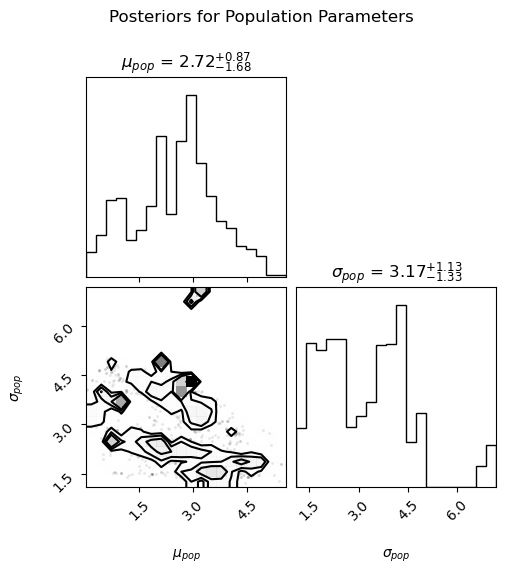

In [204]:
labels_hyper = [r"$\mu_{pop}$", r"$\sigma_{pop}$"]

# Corner plot for the population-level parameters
fig_hyper = corner.corner(
    hyper_samples,
    labels=labels_hyper,
    show_titles=True
)
plt.suptitle("Posteriors for Population Parameters", y=1.05)
plt.show()

We use a corner plot to visualize the joint and marginalized posterior distributions for our population hyperparameters, $\mu_{pop}$ and $\sigma_{pop}$. The marginalized posteriors provide the one-dimensional probability distributions for each parameter, allowing us to determine the most likely values and their associated uncertainties. The off-diagonal plot reveals the covariance between the population mean and the standard deviation. This visualization is crucial for diagnosing the health of our MCMC run; a well-defined, localized "cloud" indicates that the data has successfully constrained the global properties of our AGN sample. Here, this does not seem to be the case.

#### Plotting the inferred population distribution

Inferred Population Mean: 2.72
Inferred Population Std Dev: 3.17


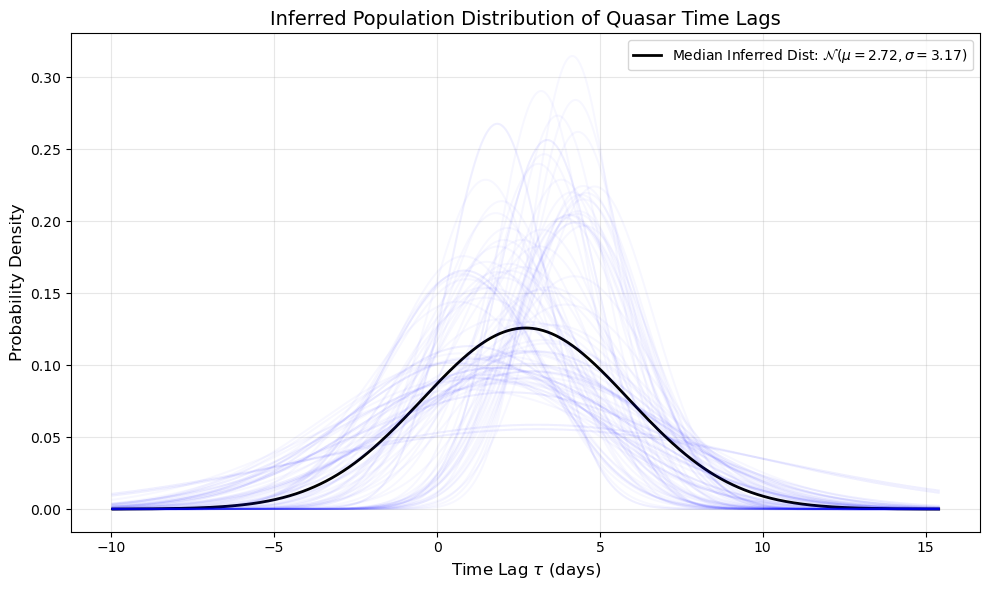

In [227]:
# Extract "best estimate"
mu_inferred, sigma_inferred = np.median(hyper_samples, axis=0)

print(f"Inferred Population Mean: {mu_inferred:.2f}")
print(f"Inferred Population Std Dev: {sigma_inferred:.2f}")

# Set up a grid of x-values (time lags) to plot the distribution
x_grid = np.linspace(mu_inferred - 4 * sigma_inferred, mu_inferred + 4 * sigma_inferred, 1000)

# Calculate the probability density function (PDF)
# This is the Normal distribution P(theta | phi)
pdf_inferred = (1.0 / (sigma_inferred * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_grid - mu_inferred) / sigma_inferred)**2)

# Initialize the plot
plt.figure(figsize=(10, 6))

# Plot the primary "best fit" distribution
plt.plot(x_grid, pdf_inferred, label=rf"Median Inferred Dist: $\mathcal{{N}}(\mu={mu_inferred:.2f}, \sigma={sigma_inferred:.2f})$", color='black', lw=2)

# Plot "uncertainty PDFs" in blue
# We randomly select 100 parameter pairs from our posterior chain and plot their resulting distributions as highly transparent lines.
num_samples_to_plot = 100
random_indices = np.random.randint(len(hyper_samples), size=num_samples_to_plot)

# Extract the random samples
sample_mus = hyper_samples[random_indices, 0]
sample_sigmas = hyper_samples[random_indices, 1]

# Calculate and plot the PDF for each random sample 
for s_mu, s_sigma in zip(sample_mus, sample_sigmas):
    sample_pdf = (1.0 / (s_sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_grid - s_mu) / s_sigma)**2)
    plt.plot(x_grid, sample_pdf, color='blue', alpha=0.03) # Low alpha creates a shaded uncertainty band

# Formatting
plt.xlabel(r"Time Lag $\tau$ (days)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.title("Inferred Population Distribution of Quasar Time Lags", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

To move from abstract parameter space back to physical reality, we reconstruct the probability density function of the time lags. In the plot above, the solid black line represents the "best-fit" population distribution using the median values of our hyperparameters. However, a single line doesn't capture Bayesian uncertainty. To visualize the range of distributions consistent with our data, we overlay random "realizations" of the population distribution drawn directly from our MCMC chains. This shaded-blue uncertainty demonstrates not just where the AGN lags are centered, but how much our confidence in that distribution fluctuates based on the available data.

#### Future Improvements

By using a normal distribution for the population level, the model technically allows for negative time lags (as we see in the "inferred population distribution" plot above). In the context of AGNs and accretion disks, we expect a signal to propagate outward from hotter (bluer) to cooler (redder) regions (i.e. we expect the lag to be positive from u-band to g-band, for example). Therefore, a negative lag might be unphysical. Switching to a log-normal distribution could be a smarter choice (it is naturally bounded at zero).

Another issue is that the lightcurves in my data are irregularly sampled. I believe I would need to use Gaussian Processes (GP) to solve this issue (like I know Weixiang did with EzTaoX - this is where my data comes from). Using interp1d is an "easy" alternatuve I found online. It assumes the light curve behaves linearly between observations, which is rarely true for stochastic variations of AGNs. A GP model would provide a much more rigorous treatment of the gaps in the data and the associated uncertainties.